[2026-07-29 09:26:48] [info     ] 计算因子，区间：2020-01-01 00:00:00 ~ 2024-12-31 23:59:59


[2026-07-29 09:41:28] [info     ] 读取因子库，区间：2020-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-29 09:41:29] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-29 09:41:40] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-29 09:41:45] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-29 09:41:52] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2020-01-02 至 2024-12-31
[2026-07-29 09:41:52] [info     ] ========== 数据检查 ==========
[2026-07-29 09:41:52] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset

时段,IC
2020-02-03~2020-03-31,0.0083
2024-01-15~2024-02-08,0.0324
2024-09-24~2024-10-08,-0.0118

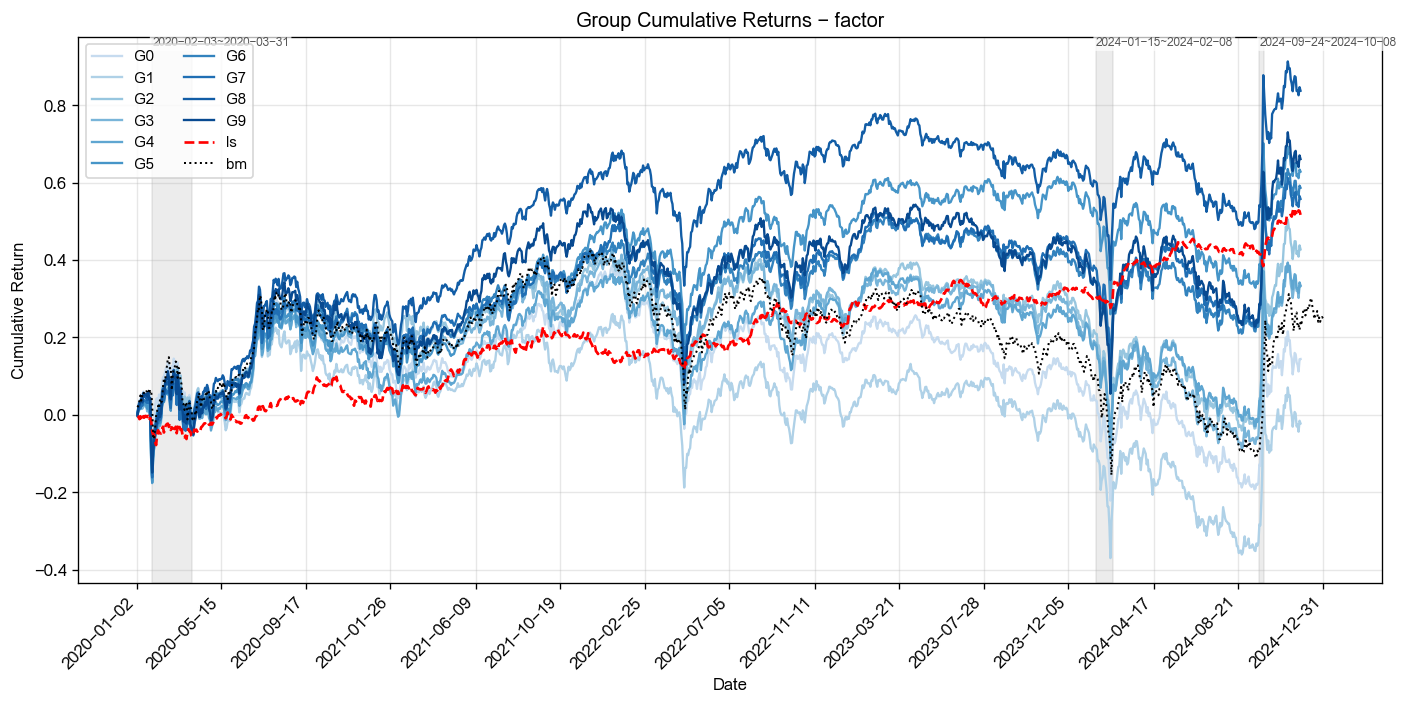
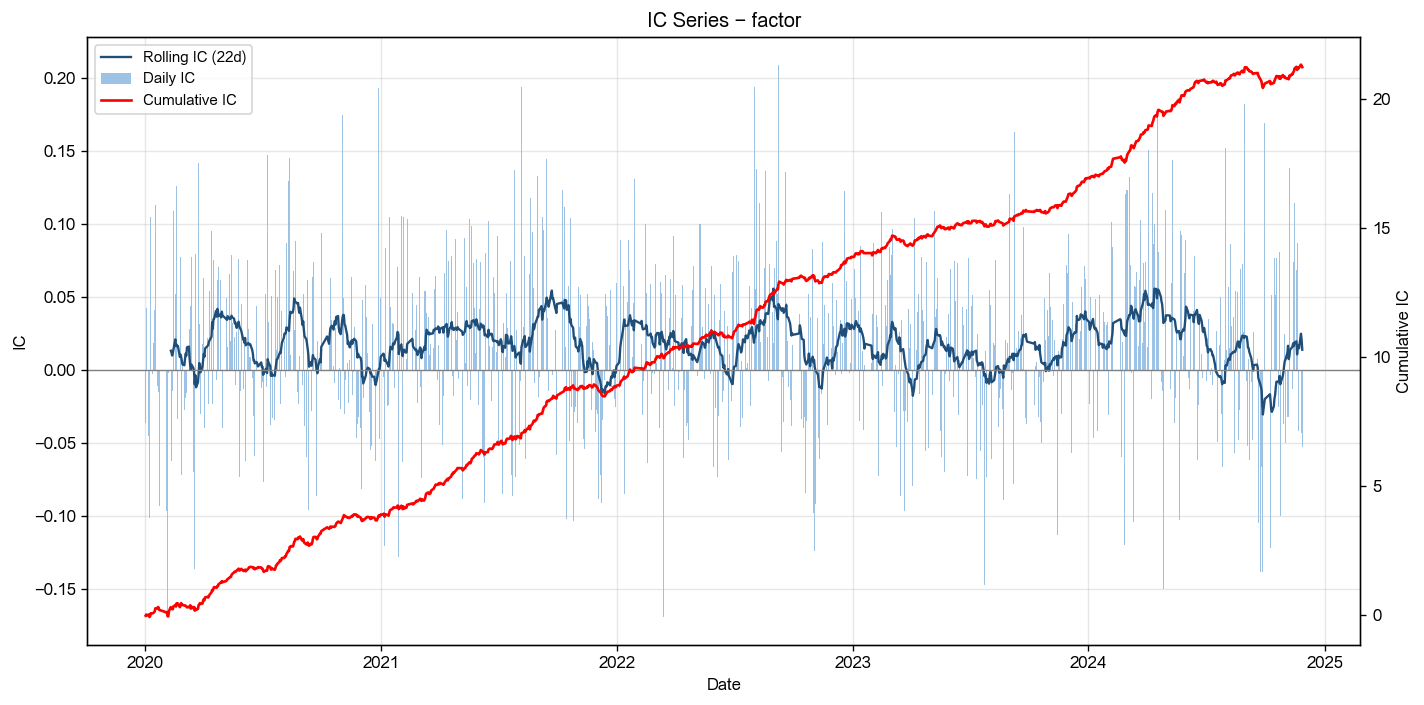
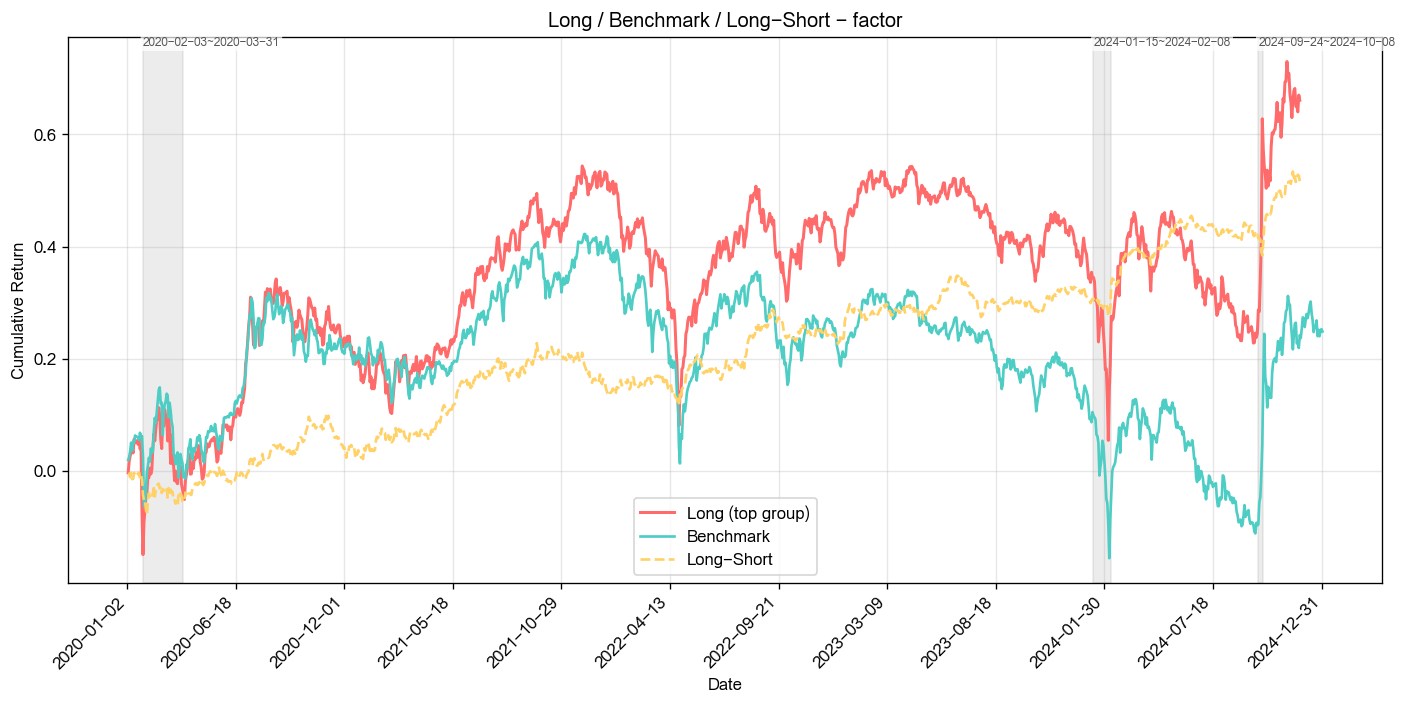
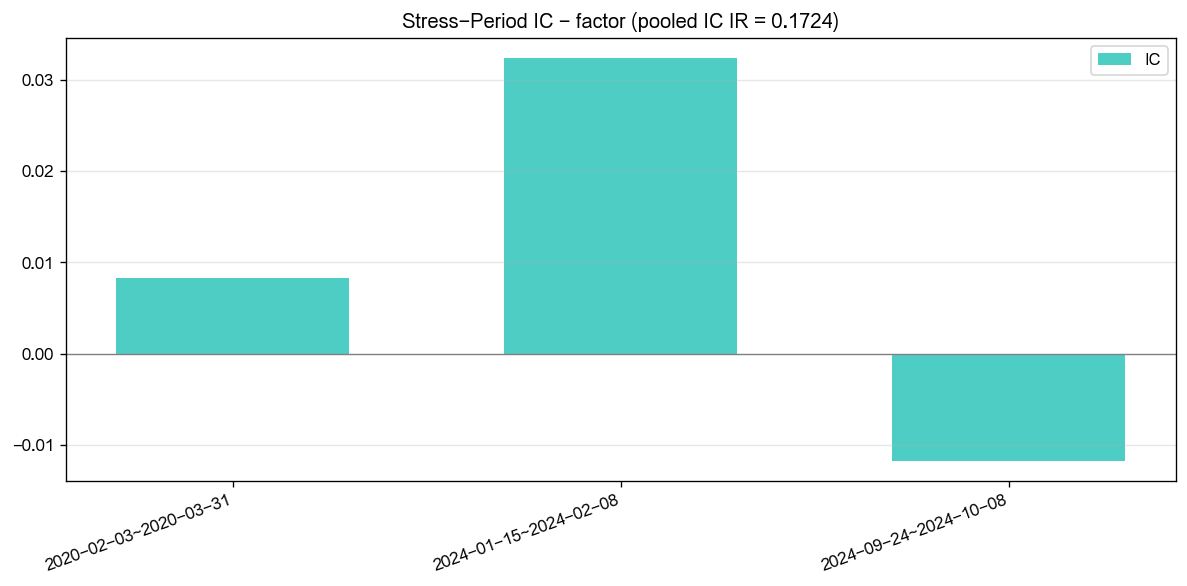
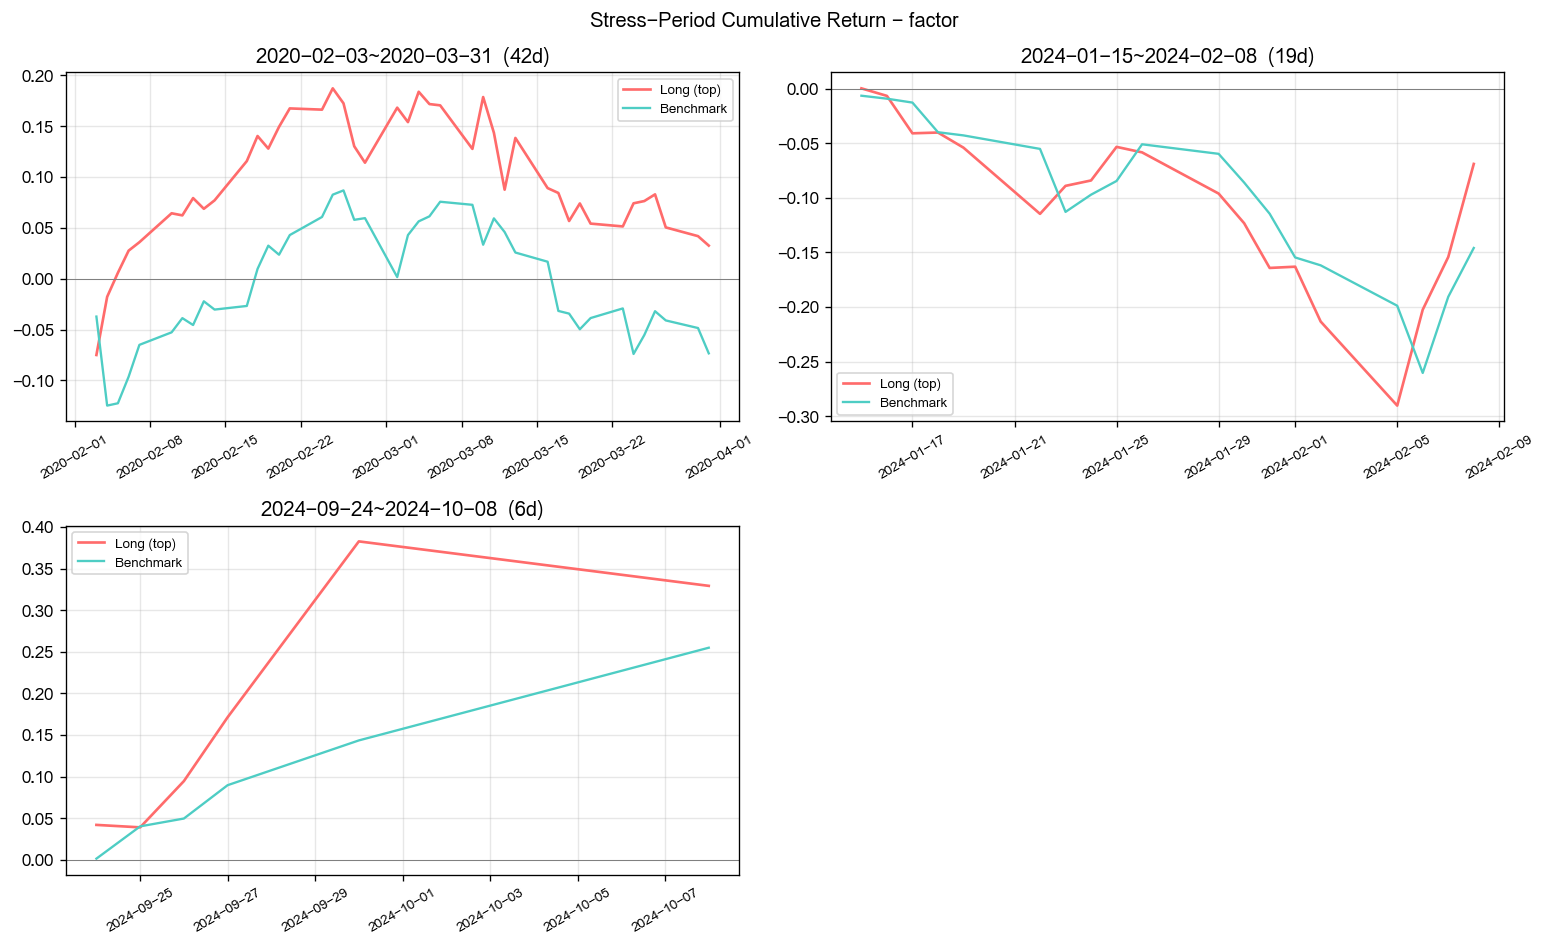

[2026-07-29 09:45:49] [info     ] ========== 因子池回归 ==========
[2026-07-29 09:45:51] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1913 rows=2121649 start_date=2020-01-02
[2026-07-29 09:45:59] [info     ] 获取收益率数据, 耗时: 9.598 秒
[2026-07-29 09:46:04] [info     ] 滚动 Elastic Net 拟合, 耗时: 5.7032 秒
[2026-07-29 09:46:04] [info     ] 统计 回归结果, 耗时: 0.0065 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,beta_000300SH_22,1.5635,0.0184,0.0118,0.9655
2,bias_20,1.4032,0.0308,0.0219,0.8966
3,turn,1.3970,0.0256,0.0183,0.9310
4,net_active_buy_amount_main,1.3755,0.0180,0.0131,0.9828
5,volatility_5,1.3604,0.0137,0.0101,0.9310
6,macd_hist_12_26_9,1.3602,0.0094,0.0069,0.9655
7,momentum_5,1.3509,0.0165,0.0122,0.9483
8,rsi_12,1.3191,0.0315,0.0239,0.9138
9,gross_profit_rate_ttm,1.2730,0.0116,0.0091,0.9655
10,net_profit_rate_ttm,1.2682,0.0067,0.0053,0.9138

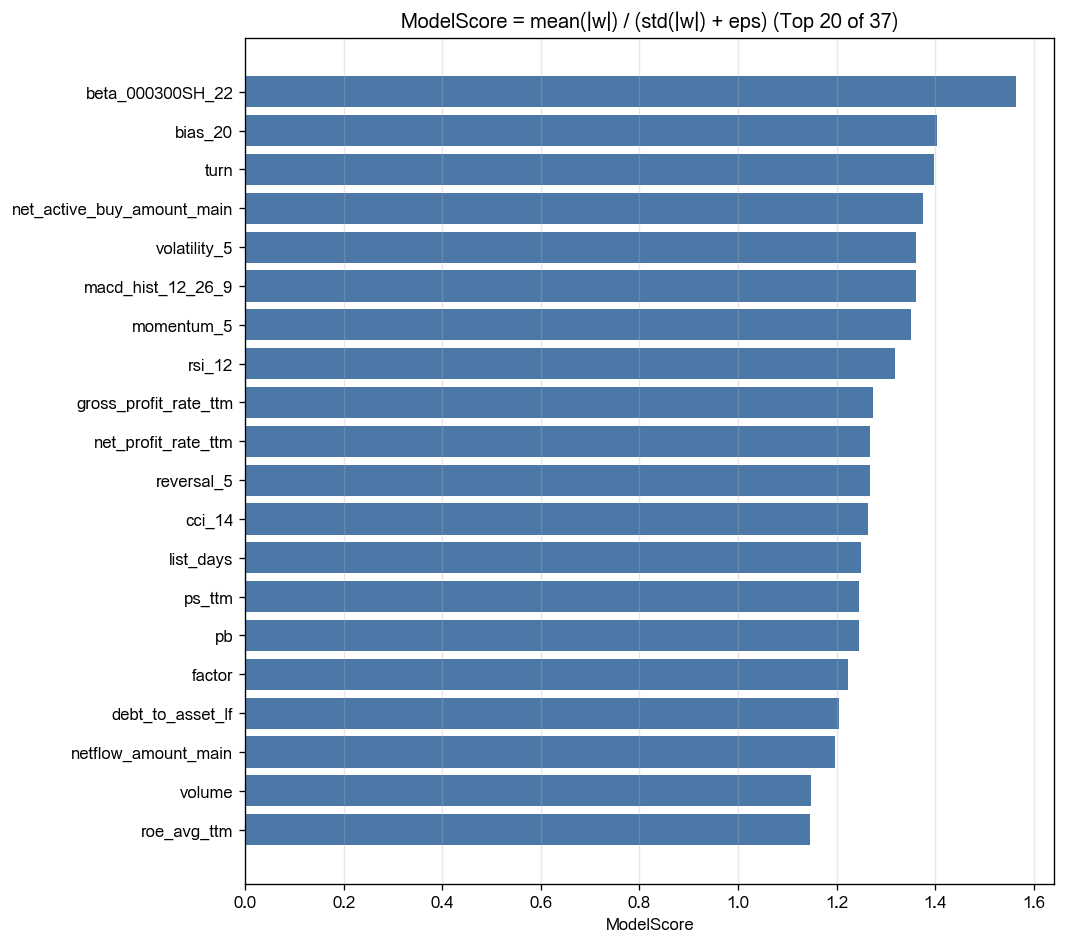
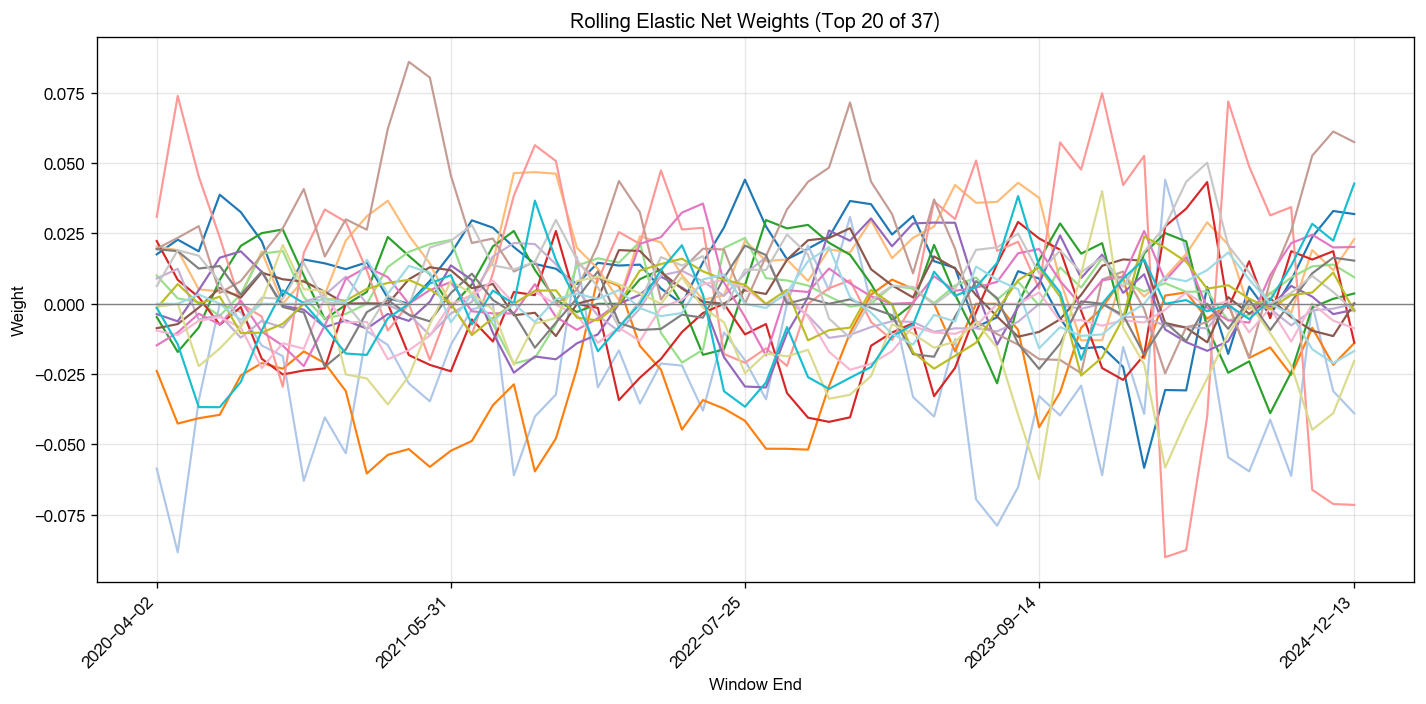
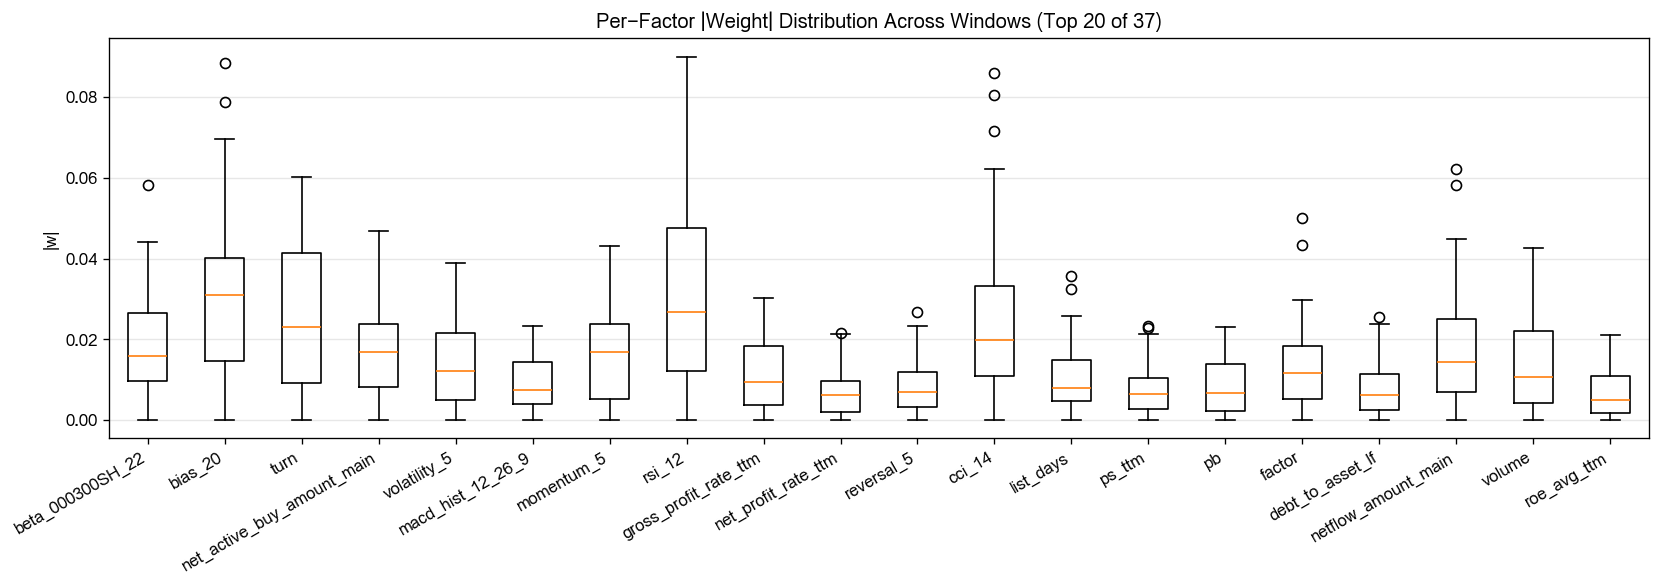
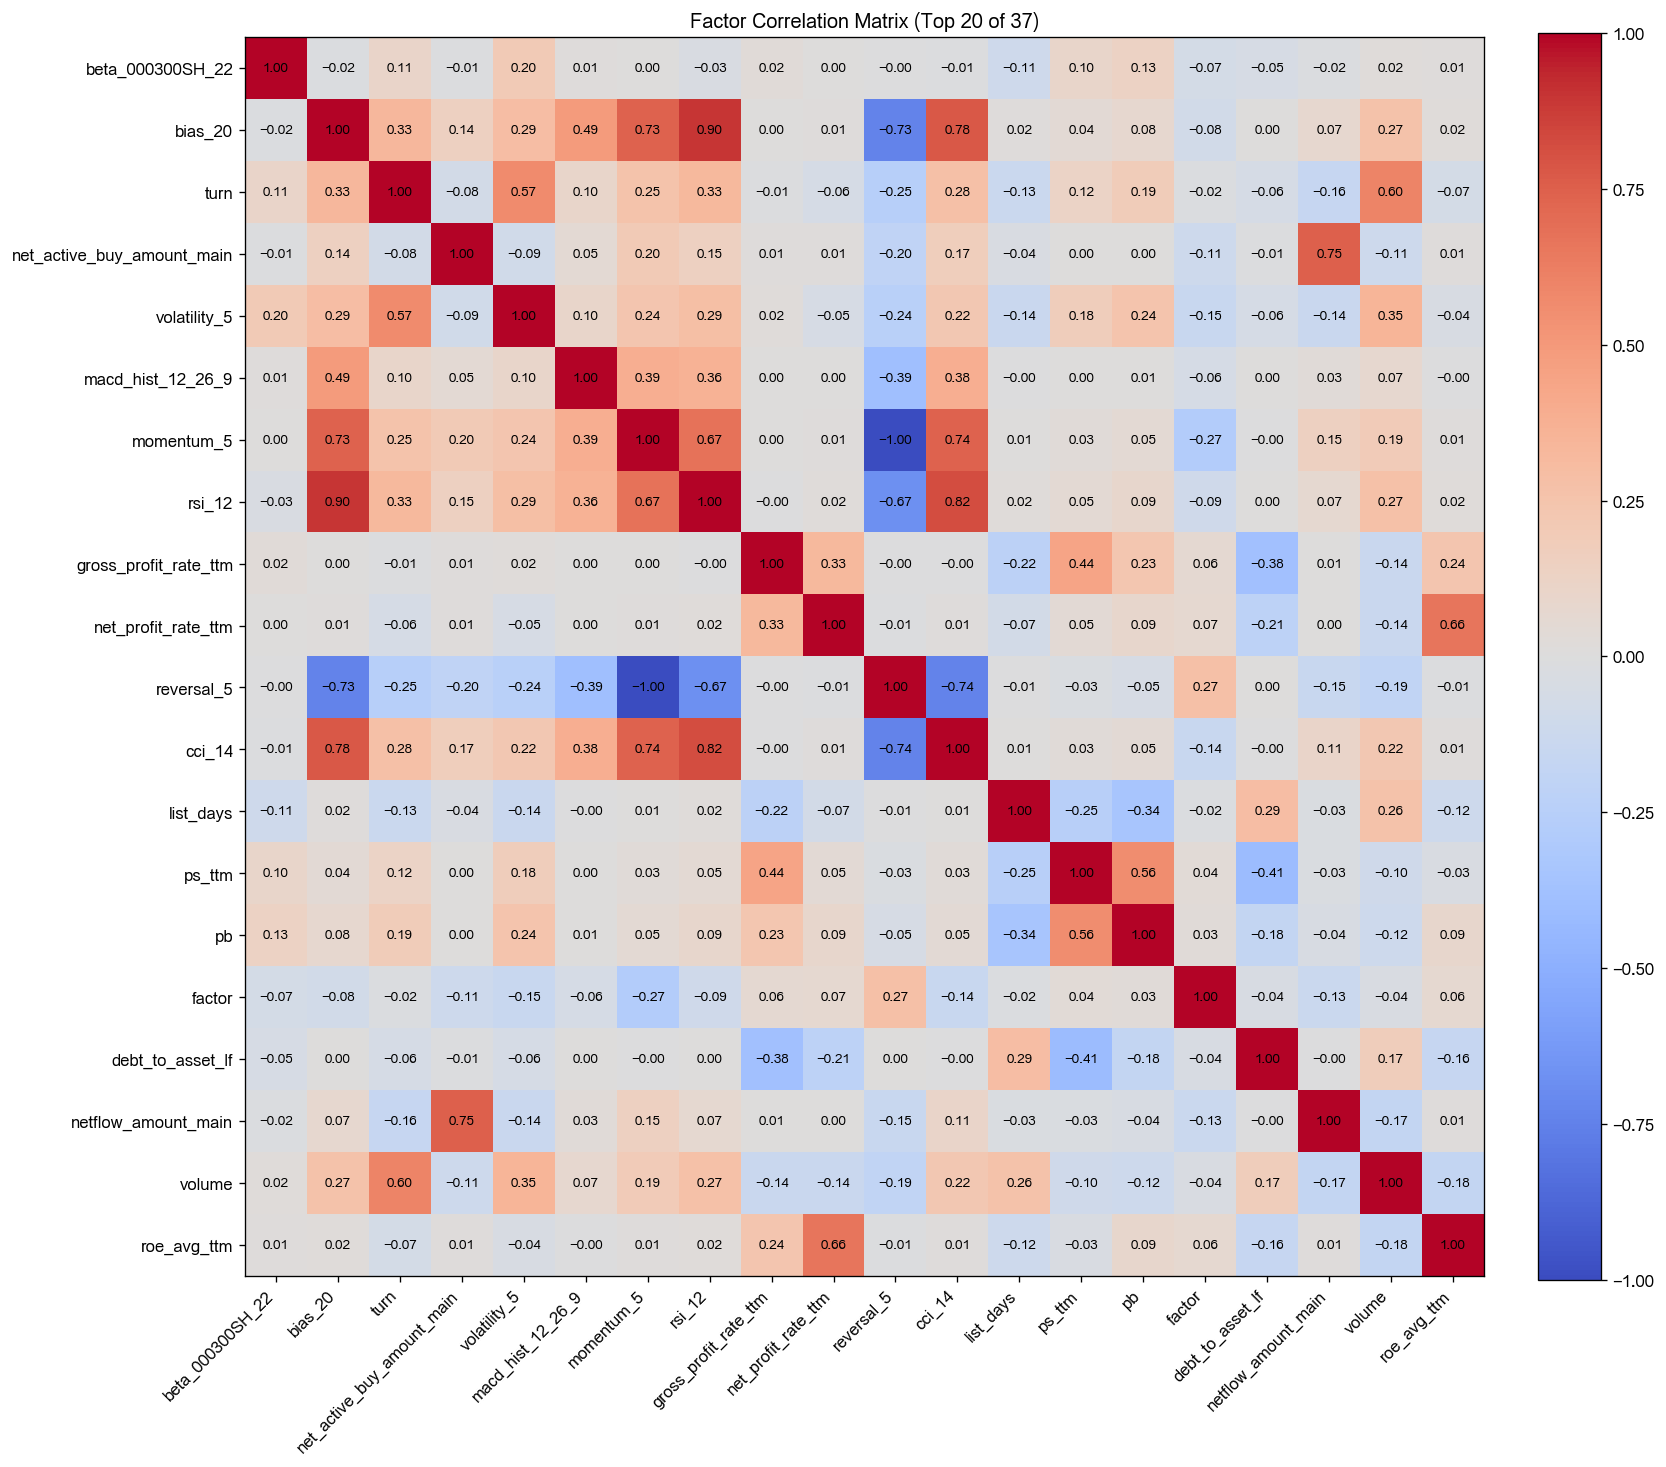

[2026-07-29 09:46:08] [warning  ] 返回的Outputs实例(size=173822714) 大于 64K, 将不会被缓存
[2026-07-29 09:46:08] [info     ] bigalpha_eval.v4 运行完成 [267.469s].


In [2]:
"""
A股市场状态 × 相对股票池 × 专家因子：条件选股因子初稿。

因子观测日为 T，供 T+1 日使用。代码只使用 T 日收盘前已经形成的分钟行情、
盘口快照和截至 T 日已经公告的财务数据。

注意
----
BigAlpha 2026 的评测股票池为历史中证1000成分股，因此本文件中的“大盘/小盘”
是每日评测截面内的相对规模分组，并不等同于全A股绝对大盘股和小盘股。

本文件是研究初稿。市场状态、股票池归属和专家因子都采用连续权重，便于后续
分别做单调性、分状态IC和消融测试，而不是直接使用容易发生边界跳变的硬切换。
"""


def main(datasources, start_date, end_date):
    """构建市场状态与股票池条件化的综合因子。

    Parameters
    ----------
    datasources : dict
        数据源映射。本因子使用 ``datasources["bar1m"]`` 和
        ``datasources["financial"]``。
    start_date, end_date : str
        因子计算区间。

    Returns
    -------
    pandas.DataFrame
        仅包含 ``date``、``instrument``、``factor`` 三列。
    """
    import numpy as np
    import pandas as pd
    import dai

    bar1m_table = datasources["bar1m"]
    financial_table = datasources["financial"]

    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)

    # 180个自然日用于60个交易日的市场状态基准和20日个股特征。
    query_start_ts = start_ts.normalize() - pd.Timedelta(days=180)
    query_end_ts = (
        end_ts.normalize()
        + pd.Timedelta(days=1)
        - pd.Timedelta(nanoseconds=1)
    )
    financial_start_ts = query_start_ts - pd.Timedelta(days=450)
    chunk_days = 7

    pool_history = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={
            "date": [
                query_start_ts,
                end_ts.normalize(),
            ]
        },
    ).df()
    pool_history["date"] = pd.to_datetime(
        pool_history["date"]
    ).dt.normalize()
    pool_history = (
        pool_history[["date", "instrument"]]
        .drop_duplicates()
        .sort_values(["date", "instrument"])
        .reset_index(drop=True)
    )

    instruments = pool_history["instrument"].drop_duplicates()
    instrument_sql = ", ".join(
        f"'{str(instrument).replace(chr(39), chr(39) * 2)}'"
        for instrument in instruments
    )

    bar_sql = f"""
    SELECT
        date,
        instrument,
        pre_close,
        open AS open_price,
        high AS high_price,
        low AS low_price,
        close AS close_price,
        deal_number,
        volume,
        amount,
        bid_price1,
        ask_price1,
        bid_volume1,
        ask_volume1
    FROM {bar1m_table}
    WHERE close > 0
    AND amount > 0
    AND deal_number > 0
    AND instrument IN ({instrument_sql})
    """

    stock_day = ["instrument", "trade_date"]

    def aggregate_bar_chunk(chunk_start, chunk_end):
        """把一批分钟行情压缩为每日价格、流动性和微观结构特征。"""
        bars = dai.query(
            bar_sql,
            filters={"date": [chunk_start, chunk_end]},
        ).df()

        bars["date"] = pd.to_datetime(bars["date"])
        bars["trade_date"] = bars["date"].dt.normalize()
        bars["minute"] = bars["date"].dt.hour * 60 + bars["date"].dt.minute

        continuous_auction = (
            bars["minute"].between(9 * 60 + 30, 11 * 60 + 30)
            | bars["minute"].between(13 * 60, 15 * 60)
        )
        bars = bars.loc[continuous_auction].copy()
        bars.sort_values(["instrument", "trade_date", "date"], inplace=True)

        previous_close = bars.groupby(
            stock_day,
            sort=False,
        )["close_price"].shift()
        tick_direction = np.sign(bars["close_price"] - previous_close)
        tick_direction = tick_direction.fillna(
            np.sign(bars["close_price"] - bars["pre_close"])
        )

        valid_quote = (
            bars["bid_price1"].gt(0)
            & bars["ask_price1"].gt(0)
            & bars["ask_price1"].ge(bars["bid_price1"])
        )
        midquote = (
            (bars["bid_price1"] + bars["ask_price1"]) / 2
        ).where(valid_quote)
        quote_direction = np.sign(bars["close_price"] - midquote)
        bars["trade_direction"] = tick_direction.where(
            tick_direction.ne(0) & tick_direction.notna(),
            quote_direction,
        ).fillna(0.0)
        bars["signed_amount"] = bars["trade_direction"] * bars["amount"]

        # 平均单笔成交额较高的分钟被赋予更大的“机构交易代理”权重。
        bars["avg_trade_amount"] = (
            bars["amount"] / bars["deal_number"]
        ).replace([np.inf, -np.inf], np.nan)
        trade_size_rank = bars.groupby(
            stock_day,
            sort=False,
        )["avg_trade_amount"].rank(
            method="average",
            pct=True,
        )
        bars["large_trade_weight"] = (
            (trade_size_rank - 0.8) / 0.2
        ).clip(lower=0.0, upper=1.0)
        bars["large_signed_amount"] = (
            bars["signed_amount"] * bars["large_trade_weight"]
        )
        bars["large_amount"] = (
            bars["amount"] * bars["large_trade_weight"]
        )

        # 一档OFI代理：报价变优时加入当前挂单量，变差时扣除上一时点挂单量。
        previous_bid_price = bars.groupby(
            stock_day,
            sort=False,
        )["bid_price1"].shift()
        previous_ask_price = bars.groupby(
            stock_day,
            sort=False,
        )["ask_price1"].shift()
        previous_bid_volume = bars.groupby(
            stock_day,
            sort=False,
        )["bid_volume1"].shift()
        previous_ask_volume = bars.groupby(
            stock_day,
            sort=False,
        )["ask_volume1"].shift()

        bid_ofi = np.where(
            bars["bid_price1"].gt(previous_bid_price),
            bars["bid_volume1"],
            np.where(
                bars["bid_price1"].eq(previous_bid_price),
                bars["bid_volume1"] - previous_bid_volume,
                -previous_bid_volume,
            ),
        )
        ask_ofi = np.where(
            bars["ask_price1"].lt(previous_ask_price),
            -bars["ask_volume1"],
            np.where(
                bars["ask_price1"].eq(previous_ask_price),
                previous_ask_volume - bars["ask_volume1"],
                previous_ask_volume,
            ),
        )
        bars["ofi"] = pd.Series(
            bid_ofi + ask_ofi,
            index=bars.index,
        ).where(valid_quote, 0.0)
        bars["book_depth"] = (
            bars["bid_volume1"].clip(lower=0)
            + bars["ask_volume1"].clip(lower=0)
        )

        bars["quoted_spread"] = (
            (bars["ask_price1"] - bars["bid_price1"]) / midquote
        ).where(valid_quote)
        bars["price_1000"] = bars["close_price"].where(
            bars["minute"].le(10 * 60)
        )

        daily_part = bars.groupby(
            stock_day,
            sort=False,
            as_index=False,
        ).agg(
            pre_close=("pre_close", "first"),
            open_price=("open_price", "first"),
            price_1000=("price_1000", "last"),
            close_price=("close_price", "last"),
            high_price=("high_price", "max"),
            low_price=("low_price", "min"),
            total_amount=("amount", "sum"),
            total_volume=("volume", "sum"),
            total_deals=("deal_number", "sum"),
            signed_amount=("signed_amount", "sum"),
            large_signed_amount=("large_signed_amount", "sum"),
            large_amount=("large_amount", "sum"),
            ofi=("ofi", "sum"),
            book_depth=("book_depth", "sum"),
            quoted_spread=("quoted_spread", "mean"),
            bar_count=("date", "size"),
        )
        return daily_part

    chunk_starts = pd.date_range(
        query_start_ts,
        query_end_ts,
        freq=f"{chunk_days}D",
    )
    daily_parts = []
    for chunk_start in chunk_starts:
        chunk_end = min(
            chunk_start
            + pd.Timedelta(days=chunk_days)
            - pd.Timedelta(nanoseconds=1),
            query_end_ts,
        )
        daily_parts.append(
            aggregate_bar_chunk(chunk_start, chunk_end)
        )

    daily = (
        pd.concat(daily_parts, ignore_index=True)
        .sort_values(["instrument", "trade_date"])
        .reset_index(drop=True)
    )

    # ------------------------------------------------------------------
    # 个股日频底层特征：所有滚动基准只使用当日及之前的数据。
    # ------------------------------------------------------------------
    daily["daily_return"] = (
        daily["close_price"] / daily["pre_close"] - 1
    ).replace([np.inf, -np.inf], np.nan)
    daily["log_return"] = np.log1p(
        daily["daily_return"].clip(
            lower=-0.95,
            upper=1.0,
        )
    )
    log_return_history = daily.groupby(
        "instrument",
        sort=False,
    )["log_return"]
    daily["return_5"] = log_return_history.transform(
        lambda values: np.expm1(
            values.rolling(
                5,
                min_periods=3,
            ).sum()
        )
    )
    daily["momentum_20"] = log_return_history.transform(
        lambda values: np.expm1(
            values.rolling(
                20,
                min_periods=10,
            ).sum()
        )
    )

    return_history = daily.groupby(
        "instrument",
        sort=False,
    )["daily_return"]
    daily["volatility_20"] = return_history.transform(
        lambda values: values.rolling(
            20,
            min_periods=10,
        ).std()
    )

    amount_history = daily.groupby(
        "instrument",
        sort=False,
    )["total_amount"]
    daily["amount_baseline_20"] = amount_history.transform(
        lambda values: values.shift(1).rolling(
            20,
            min_periods=10,
        ).median()
    )
    daily["amount_shock"] = np.log(
        (
            daily["total_amount"]
            / daily["amount_baseline_20"]
        ).clip(lower=1e-4, upper=100.0)
    )

    daily["large_flow"] = (
        daily["large_signed_amount"] / daily["large_amount"]
    ).replace([np.inf, -np.inf], np.nan)
    daily["ofi_ratio"] = (
        daily["ofi"] / daily["book_depth"]
    ).replace([np.inf, -np.inf], np.nan)

    def causal_stock_zscore(values, window=10, min_periods=5):
        """用该股票截至上一交易日的历史分布标准化当日观测。"""
        baseline = values.shift(1).rolling(
            window,
            min_periods=min_periods,
        )
        mean = baseline.mean()
        std = baseline.std().where(
            lambda scale: scale.gt(1e-8)
        )
        return (values - mean) / std

    daily["flow_z"] = daily.groupby(
        "instrument",
        sort=False,
    )["large_flow"].transform(causal_stock_zscore)
    daily["ofi_z"] = daily.groupby(
        "instrument",
        sort=False,
    )["ofi_ratio"].transform(causal_stock_zscore)

    daily["intraday_range"] = (
        (daily["high_price"] - daily["low_price"])
        / daily["open_price"]
    ).replace([np.inf, -np.inf], np.nan)
    early_return = (
        daily["price_1000"] / daily["open_price"] - 1
    )
    late_return = (
        daily["close_price"] / daily["price_1000"] - 1
    )
    close_location = (
        (daily["close_price"] - daily["low_price"])
        / (daily["high_price"] - daily["low_price"])
    ).replace([np.inf, -np.inf], np.nan)
    daily["shape_score"] = (
        late_return
        - early_return
        + (2 * close_location - 1) * daily["intraday_range"]
    )

    signals = daily.rename(columns={"trade_date": "date"})[
        [
            "date",
            "instrument",
            "daily_return",
            "return_5",
            "momentum_20",
            "volatility_20",
            "total_amount",
            "amount_shock",
            "intraday_range",
            "quoted_spread",
            "flow_z",
            "ofi_z",
            "shape_score",
        ]
    ]

    # ------------------------------------------------------------------
    # 财务底层特征：date为公告日；稍后只允许向后匹配最近已公告数据。
    # ------------------------------------------------------------------
    financial_sql = f"""
    WITH ttm_current AS (
        SELECT
            date,
            instrument,
            net_profit_to_parent_shareholders AS net_profit_ttm,
            net_cffoa AS net_cffoa_ttm,
            operating_revenue AS revenue_ttm
        FROM {financial_table}
        WHERE category = 'ttm' AND shift = 0
    ),
    ttm_previous_year AS (
        SELECT
            date,
            instrument,
            operating_revenue AS revenue_ttm_previous_year
        FROM {financial_table}
        WHERE category = 'ttm' AND shift = 4
    ),
    latest_financial AS (
        SELECT
            date,
            instrument,
            total_owner_equity AS owner_equity_lf,
            total_liabilities AS liabilities_lf,
            total_assets AS assets_lf
        FROM {financial_table}
        WHERE category = 'lf' AND shift = 0
    )
    SELECT
        date,
        instrument,
        net_profit_ttm / owner_equity_lf AS roe,
        net_cffoa_ttm / ABS(net_profit_ttm) AS cf_quality,
        net_profit_ttm / revenue_ttm AS profit_margin,
        revenue_ttm / ABS(revenue_ttm_previous_year) - 1 AS revenue_growth,
        -liabilities_lf / assets_lf AS low_leverage,
        assets_lf AS size_proxy
    FROM ttm_current
    PRUNE JOIN latest_financial USING (date, instrument)
    PRUNE JOIN ttm_previous_year USING (date, instrument)
    """
    financial = dai.query(
        financial_sql,
        filters={
            "date": [
                financial_start_ts,
                end_ts.normalize(),
            ]
        },
    ).df()
    financial["date"] = pd.to_datetime(
        financial["date"]
    ).dt.normalize()
    financial_columns = [
        "roe",
        "cf_quality",
        "profit_margin",
        "revenue_growth",
        "low_leverage",
        "size_proxy",
    ]
    financial[financial_columns] = financial[
        financial_columns
    ].replace([np.inf, -np.inf], np.nan)
    financial = (
        financial[["date", "instrument", *financial_columns]]
        .drop_duplicates(["date", "instrument"], keep="last")
        .sort_values(["date", "instrument"])
    )

    factor = pool_history.merge(
        signals,
        how="left",
        on=["date", "instrument"],
    )
    factor = pd.merge_asof(
        factor.sort_values(["date", "instrument"]),
        financial,
        on="date",
        by="instrument",
        direction="backward",
        allow_exact_matches=True,
    ).sort_values(["instrument", "date"])

    def daily_rank(values, ascending=True):
        """每日截面百分位排名。"""
        return values.groupby(
            factor["date"],
            sort=False,
        ).rank(
            method="average",
            pct=True,
            ascending=ascending,
        )

    def centered_daily_rank(values, ascending=True):
        """每日截面排名后居中，保持专家信号量纲一致。"""
        ranked = daily_rank(values, ascending=ascending)
        return ranked - ranked.groupby(
            factor["date"],
            sort=False,
        ).transform("mean")

    # ==================================================================
    # 第一部分：定义各类基础专家因子
    # ==================================================================
    def build_expert_factors(frame):
        """定义动量、反转、低波、质量和机构行为五类专家信号。"""
        frame["momentum_alpha"] = centered_daily_rank(
            frame["momentum_20"]
        )
        frame["reversal_alpha"] = -centered_daily_rank(
            frame["return_5"]
        )
        frame["low_vol_alpha"] = -centered_daily_rank(
            frame["volatility_20"]
        )

        quality_components = []
        for column in [
            "roe",
            "cf_quality",
            "profit_margin",
            "revenue_growth",
            "low_leverage",
        ]:
            quality_components.append(
                centered_daily_rank(frame[column])
            )
        frame["quality_alpha"] = pd.concat(
            quality_components,
            axis=1,
        ).mean(axis=1)

        flow_alpha = centered_daily_rank(frame["flow_z"])
        shape_alpha = -centered_daily_rank(frame["shape_score"])
        ofi_alpha = centered_daily_rank(frame["ofi_z"])

        # 延续已验证的003形态主导结构，OFI只作为较小的确认项。
        frame["institution_alpha"] = (
            0.70 * shape_alpha
            + 0.20 * flow_alpha
            + 0.10 * ofi_alpha
        )

        alpha_columns = [
            "momentum_alpha",
            "reversal_alpha",
            "low_vol_alpha",
            "quality_alpha",
            "institution_alpha",
        ]
        frame[alpha_columns] = frame[alpha_columns].fillna(0.0)
        return frame

    factor = build_expert_factors(factor)

    # ==================================================================
    # 第二部分：定义软股票池分类
    # ==================================================================
    def build_pool_memberships(frame):
        """定义核心、成长活跃、交易活跃和防御四类软归属权重。"""
        frame["size_rank"] = daily_rank(
            np.log1p(frame["size_proxy"].clip(lower=0))
        ).fillna(0.5)
        frame["liquidity_rank"] = daily_rank(
            np.log1p(frame["total_amount"].clip(lower=0))
        ).fillna(0.5)
        frame["volatility_rank"] = daily_rank(
            frame["volatility_20"]
        ).fillna(0.5)
        spread_rank = daily_rank(
            frame["quoted_spread"]
        ).fillna(0.5)

        amount_activity = daily_rank(
            frame["amount_shock"]
        ).fillna(0.5)
        range_activity = daily_rank(
            frame["intraday_range"]
        ).fillna(0.5)
        frame["activity_rank"] = (
            0.45 * amount_activity
            + 0.30 * range_activity
            + 0.25 * frame["volatility_rank"]
        )

        large = frame["size_rank"]
        small = 1.0 - frame["size_rank"]
        liquid = frame["liquidity_rank"]
        stable = 1.0 - frame["activity_rank"]

        frame["core_pool"] = (
            large * liquid * (0.5 + 0.5 * stable)
        )
        frame["growth_pool"] = (
            small * liquid * (0.5 + 0.5 * stable)
        )
        frame["active_pool"] = (
            (0.3 + 0.7 * small)
            * liquid
            * frame["activity_rank"]
        )
        frame["defensive_pool"] = (
            (0.4 + 0.6 * large)
            * (1.0 - frame["volatility_rank"])
            * (0.5 + 0.5 * liquid)
        )

        pool_columns = [
            "core_pool",
            "growth_pool",
            "active_pool",
            "defensive_pool",
        ]
        pool_total = frame[pool_columns].sum(axis=1).where(
            lambda values: values.gt(1e-8),
            1.0,
        )
        frame[pool_columns] = frame[pool_columns].div(
            pool_total,
            axis=0,
        )

        institution_strength = (
            frame["institution_alpha"].abs()
        )
        frame["event_membership"] = daily_rank(
            institution_strength
        ).fillna(0.0)
        frame["illiquidity_risk"] = (
            (1.0 - liquid)
            * (0.5 + 0.5 * spread_rank)
        )
        return frame

    factor = build_pool_memberships(factor)

    # ==================================================================
    # 第三部分：定义市场meta-indicator
    # ==================================================================
    def build_market_meta(frame):
        """构造风险状态、相对风格和市场修复状态三个meta-indicator。"""
        positive_momentum = frame["momentum_20"].gt(0).where(
            frame["momentum_20"].notna()
        )
        downside_tail = frame["daily_return"].lt(-0.05).where(
            frame["daily_return"].notna()
        )

        meta = frame.groupby(
            "date",
            sort=True,
            as_index=False,
        ).agg(
            market_return=("daily_return", "mean"),
            market_amount=("total_amount", "sum"),
            return_dispersion=("daily_return", "std"),
        )

        # 布局宽度和尾部占比由带缺失掩码的布尔Series显式聚合。
        breadth = positive_momentum.groupby(
            frame["date"],
            sort=True,
        ).mean()
        tail = downside_tail.groupby(
            frame["date"],
            sort=True,
        ).mean()
        meta = meta.set_index("date")
        meta["breadth_20"] = breadth
        meta["tail_ratio"] = tail

        small_return = frame.loc[
            frame["size_rank"].le(0.3)
        ].groupby(
            "date",
            sort=True,
        )["daily_return"].mean()
        large_return = frame.loc[
            frame["size_rank"].ge(0.7)
        ].groupby(
            "date",
            sort=True,
        )["daily_return"].mean()
        meta["small_large_return"] = (
            small_return - large_return
        )

        safe_market_return = meta["market_return"].clip(
            lower=-0.95,
            upper=1.0,
        )
        meta["market_trend_20"] = np.expm1(
            np.log1p(safe_market_return).rolling(
                20,
                min_periods=10,
            ).sum()
        )
        meta["market_volatility_20"] = meta[
            "market_return"
        ].rolling(
            20,
            min_periods=10,
        ).std()
        amount_baseline = meta["market_amount"].shift(1).rolling(
            20,
            min_periods=10,
        ).median()
        meta["liquidity_shock"] = np.log(
            (
                meta["market_amount"] / amount_baseline
            ).clip(lower=1e-4, upper=100.0)
        )
        meta["style_trend_20"] = meta[
            "small_large_return"
        ].rolling(
            20,
            min_periods=10,
        ).mean()

        def causal_market_zscore(values):
            history = values.shift(1).rolling(
                60,
                min_periods=20,
            )
            mean = history.mean()
            std = history.std().where(
                lambda scale: scale.gt(1e-8)
            )
            return ((values - mean) / std).clip(
                lower=-4.0,
                upper=4.0,
            )

        trend_z = causal_market_zscore(meta["market_trend_20"])
        breadth_z = causal_market_zscore(meta["breadth_20"])
        liquidity_z = causal_market_zscore(meta["liquidity_shock"])
        volatility_z = causal_market_zscore(
            meta["market_volatility_20"]
        )
        tail_z = causal_market_zscore(meta["tail_ratio"])

        meta["risk_score"] = (
            0.30 * trend_z
            + 0.25 * breadth_z
            + 0.20 * liquidity_z
            - 0.15 * volatility_z
            - 0.10 * tail_z
        )

        style_z = causal_market_zscore(meta["style_trend_20"])
        meta["style_score"] = style_z

        repair_raw = (
            meta["breadth_20"].diff(5)
            + meta["liquidity_shock"].diff(5)
            - meta["market_volatility_20"].diff(5)
            - meta["tail_ratio"].diff(5)
        )
        meta["repair_score"] = causal_market_zscore(repair_raw)

        def three_way_softmax(score, positive_name, negative_name, flat_name):
            clipped = pd.to_numeric(
                score,
                errors="coerce",
            ).astype(float).clip(
                lower=-6.0,
                upper=6.0,
            )
            positive = np.exp(clipped)
            negative = np.exp(-clipped)
            flat = np.exp(-clipped.abs())
            total = positive + negative + flat
            return pd.DataFrame(
                {
                    positive_name: positive / total,
                    negative_name: negative / total,
                    flat_name: flat / total,
                },
                index=score.index,
            )

        risk_weights = three_way_softmax(
            meta["risk_score"],
            "risk_on_weight",
            "risk_off_weight",
            "risk_neutral_weight",
        )
        style_weights = three_way_softmax(
            meta["style_score"],
            "small_style_weight",
            "large_style_weight",
            "balanced_style_weight",
        )
        repair_weights = three_way_softmax(
            meta["repair_score"],
            "repair_weight",
            "deterioration_weight",
            "stable_weight",
        )
        meta = pd.concat(
            [meta, risk_weights, style_weights, repair_weights],
            axis=1,
        )

        fallback_weights = {
            "risk_on_weight": 0.25,
            "risk_off_weight": 0.25,
            "risk_neutral_weight": 0.50,
            "small_style_weight": 0.25,
            "large_style_weight": 0.25,
            "balanced_style_weight": 0.50,
            "repair_weight": 0.25,
            "deterioration_weight": 0.25,
            "stable_weight": 0.50,
        }
        meta[list(fallback_weights)] = meta[
            list(fallback_weights)
        ].fillna(fallback_weights)

        return meta.reset_index()[
            [
                "date",
                "risk_score",
                "style_score",
                "repair_score",
                *fallback_weights,
            ]
        ]

    market_meta = build_market_meta(factor)
    factor = factor.merge(
        market_meta,
        how="left",
        on="date",
    )

    # ==================================================================
    # 第四部分：各股票池专家组合与最终软门控聚合
    # ==================================================================
    risk_on = factor["risk_on_weight"]
    risk_off = factor["risk_off_weight"]
    risk_neutral = factor["risk_neutral_weight"]

    # 核心相对大盘池：风险期偏质量和低波，顺风期增加中期动量。
    factor["core_expert"] = (
        risk_on
        * (
            0.55 * factor["momentum_alpha"]
            + 0.25 * factor["quality_alpha"]
            + 0.20 * factor["institution_alpha"]
        )
        + risk_neutral
        * (
            0.40 * factor["low_vol_alpha"]
            + 0.35 * factor["reversal_alpha"]
            + 0.25 * factor["quality_alpha"]
        )
        + risk_off
        * (
            0.55 * factor["low_vol_alpha"]
            + 0.35 * factor["quality_alpha"]
            + 0.10 * factor["reversal_alpha"]
        )
    )

    # 相对中小盘流动池：行情改善时动量和机构行为权重更高。
    factor["growth_expert"] = (
        risk_on
        * (
            0.40 * factor["momentum_alpha"]
            + 0.40 * factor["institution_alpha"]
            + 0.20 * factor["reversal_alpha"]
        )
        + risk_neutral
        * (
            0.45 * factor["reversal_alpha"]
            + 0.40 * factor["institution_alpha"]
            + 0.15 * factor["low_vol_alpha"]
        )
        + risk_off
        * (
            0.45 * factor["low_vol_alpha"]
            + 0.35 * factor["reversal_alpha"]
            + 0.20 * factor["quality_alpha"]
        )
    )

    # 高活跃池：以机构行为和短期反转为主，风险关闭时主动降暴露。
    factor["active_expert"] = (
        risk_on
        * (
            0.45 * factor["institution_alpha"]
            + 0.35 * factor["momentum_alpha"]
            + 0.20 * factor["reversal_alpha"]
        )
        + risk_neutral
        * (
            0.50 * factor["institution_alpha"]
            + 0.40 * factor["reversal_alpha"]
            + 0.10 * factor["momentum_alpha"]
        )
        + risk_off
        * (
            0.50 * factor["low_vol_alpha"]
            + 0.35 * factor["reversal_alpha"]
            + 0.15 * factor["institution_alpha"]
        )
    )

    # 防御池：跨状态保持低波和质量为主，减少短期交易信号干扰。
    factor["defensive_expert"] = (
        risk_on
        * (
            0.35 * factor["momentum_alpha"]
            + 0.35 * factor["low_vol_alpha"]
            + 0.30 * factor["quality_alpha"]
        )
        + risk_neutral
        * (
            0.45 * factor["low_vol_alpha"]
            + 0.35 * factor["quality_alpha"]
            + 0.20 * factor["reversal_alpha"]
        )
        + risk_off
        * (
            0.60 * factor["low_vol_alpha"]
            + 0.40 * factor["quality_alpha"]
        )
    )

    # 风格meta只做温和再加权，不替代每日个股池归属。
    factor["core_pool"] *= (
        0.75 + 0.25 * factor["large_style_weight"]
    )
    factor["growth_pool"] *= (
        0.75 + 0.25 * factor["small_style_weight"]
    )
    factor["active_pool"] *= (
        0.70
        + 0.20 * factor["small_style_weight"]
        + 0.10 * factor["repair_weight"]
    )
    factor["defensive_pool"] *= (
        0.75
        + 0.15 * factor["large_style_weight"]
        + 0.10 * factor["deterioration_weight"]
    )

    primary_score = (
        factor["core_pool"] * factor["core_expert"]
        + factor["growth_pool"] * factor["growth_expert"]
        + factor["active_pool"] * factor["active_expert"]
        + factor["defensive_pool"] * factor["defensive_expert"]
    )
    pool_total = factor[
        [
            "core_pool",
            "growth_pool",
            "active_pool",
            "defensive_pool",
        ]
    ].sum(axis=1).where(
        lambda values: values.gt(1e-8),
        1.0,
    )
    primary_score = primary_score / pool_total

    # 强机构事件只做覆盖层；非流动性风险在risk-off时加大惩罚。
    event_overlay = (
        (0.05 + 0.10 * factor["repair_weight"])
        * factor["event_membership"]
        * factor["institution_alpha"]
    )
    liquidity_penalty = (
        (0.04 + 0.08 * factor["risk_off_weight"])
        * factor["illiquidity_risk"]
    )
    factor["raw_factor"] = (
        primary_score + event_overlay - liquidity_penalty
    ).replace([np.inf, -np.inf], np.nan)

    # 最终再次做日截面排名，消除不同市场状态下的分数尺度漂移。
    final_rank = daily_rank(factor["raw_factor"])
    factor["factor"] = (
        final_rank
        - final_rank.groupby(
            factor["date"],
            sort=False,
        ).transform("mean")
    ).fillna(0.0)

    result = factor.loc[
        factor["date"].between(
            start_ts.normalize(),
            end_ts.normalize(),
        ),
        ["date", "instrument", "factor"],
    ]
    result = (
        result.sort_values(["date", "instrument"])
        .reset_index(drop=True)
    )
    return result


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        "financial": "bigalpha_2026_financial",
        "bar1m": "bigalpha_2026_stock_bar1m",
    }
    start_date = "2020-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    logger.info(
        f"计算因子，区间：{start_date} ~ {end_date}"
    )
    factor_data = main(datasources, start_date, end_date)

    expected_columns = ["date", "instrument", "factor"]
    assert factor_data.columns.tolist() == expected_columns
    assert not factor_data.duplicated(
        ["date", "instrument"]
    ).any()
    assert factor_data["factor"].notna().all()

    logger.info(
        f"读取因子库，区间：{start_date} ~ {end_date}"
    )
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
